In [53]:
import os
import pandas as pd

# Model parameters

In [54]:
import numpy as np

# Shim and Sung (2022) Table 4: Phoneme recognition accuracy (%) of DNN models with different parameter sizes
ref1 = np.array(1.04e6)
ref2 = np.array(3.09e6)
ref3 = np.array(5.04e6)

model1 = np.array([1.05e6, 1.00e6, 1.01e6])
model2 = np.array([3.02e6, 3.06e6, 2.97e6])
model3 = np.array([5.07e6, 5.09e6, 5.08e6])

print(np.average([
    np.abs(ref1 - model1), 
    np.abs(ref2 - model2),
    np.abs(ref3 - model3)
]))


# Mine
ref_mine = np.array(353296)

# CNN, GRU, Attn
# 64, 96, 96
model_mine = np.array([374480, 369968])
print(np.average(np.abs(ref_mine - model_mine)))

# 64, 92, 92
model_mine = np.array([355936, 348400])
print(np.average(np.abs(ref_mine - model_mine)))

# 64, 92, 96
model_mine = np.array([355936, 369968])
print(np.average(np.abs(ref_mine - model_mine)))

46666.666666666664
18928.0
3768.0
9656.0


# Globals

In [55]:
MELSPEC_CHUNK_LENGTHS = [5, 15, 30]

# Metadata

Tags are delimited with the "+" symbol

In [56]:
df = pd.read_csv("./autotagging_moodtheme.csv")
df.head(10)

,TRACK_ID,ARTIST_ID,ALBUM_ID,PATH,DURATION,TAGS
0,track_0000948,artist_000087,album_000149,48/948.mp3,2127,mood/theme---background
1,track_0000950,artist_000087,album_000149,50/950.mp3,2480,mood/theme---background
2,track_0000951,artist_000087,album_000149,51/951.mp3,1997,mood/theme---background
3,track_0002165,artist_000326,album_000347,65/2165.mp3,2290,mood/theme---film
4,track_0002263,artist_000320,album_000366,63/2263.mp3,4947,mood/theme---melancholic
5,track_0003346,artist_000517,album_000521,46/3346.mp3,1950,mood/theme---calm+mood/theme---melodic
6,track_0003347,artist_000517,album_000521,47/3347.mp3,2018,mood/theme---calm+mood/theme---melodic
7,track_0003348,artist_000517,album_000521,48/3348.mp3,2533,mood/theme---calm+mood/theme---melodic
8,track_0003349,artist_000517,album_000521,49/3349.mp3,2284,mood/theme---calm+mood/theme---melodic
9,track_0003350,artist_000517,album_000521,50/3350.mp3,1947,mood/theme---calm+mood/theme---melodic


In [57]:
df["TAGS"] = df["TAGS"].apply(lambda x: x.replace("mood/theme---", "").split("+"))
df[5:10]

,TRACK_ID,ARTIST_ID,ALBUM_ID,PATH,DURATION,TAGS
5,track_0003346,artist_000517,album_000521,46/3346.mp3,1950,"[calm, melodic]"
6,track_0003347,artist_000517,album_000521,47/3347.mp3,2018,"[calm, melodic]"
7,track_0003348,artist_000517,album_000521,48/3348.mp3,2533,"[calm, melodic]"
8,track_0003349,artist_000517,album_000521,49/3349.mp3,2284,"[calm, melodic]"
9,track_0003350,artist_000517,album_000521,50/3350.mp3,1947,"[calm, melodic]"


In [58]:
# this is because when exporting from .tsv to .xlsx to .csv, the decimal delimiter for the "DURATION" column was somehow erased
df["DURATION"] = df["DURATION"].apply(lambda x: x / 10.0)

In [59]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18486 entries, 0 to 18485
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TRACK_ID   18486 non-null  str    
 1   ARTIST_ID  18486 non-null  str    
 2   ALBUM_ID   18486 non-null  str    
 3   PATH       18486 non-null  str    
 4   DURATION   18486 non-null  float64
 5   TAGS       18486 non-null  object 
dtypes: float64(1), object(1), str(4)
memory usage: 866.7+ KB


In [60]:
# can isolate one row like this
df[df.eq("00/985000.mp3").any(axis=1)]

,TRACK_ID,ARTIST_ID,ALBUM_ID,PATH,DURATION,TAGS
5554,track_0985000,artist_428049,album_115967,00/985000.mp3,256.1,"[melodic, travel]"


In [61]:
df["DURATION"].describe()

count    18486.000000
mean       219.377388
std        144.209528
min         30.000000
25%        138.500000
50%        202.900000
75%        268.300000
max       3931.300000
Name: DURATION, dtype: float64

In [62]:
print("Median music duration\t:", (df["DURATION"].median()) // 60, "m", (df["DURATION"].median()) % 60, "s")
print("Mean music duration\t:", (df["DURATION"].mean()) // 60, "m", (df["DURATION"].mean()) % 60, "s")
print("Std dev music duration\t:", (df["DURATION"].std()) // 60, "m", (df["DURATION"].std()) % 60, "s")

Median music duration	: 3.0 m 22.900000000000006 s
Mean music duration	: 3.0 m 39.37738829384398 s
Std dev music duration	: 2.0 m 24.20952847587924 s


In [63]:
mcls = pd.DataFrame(columns=[f"{i}s_chunks" for i in MELSPEC_CHUNK_LENGTHS])
for i in MELSPEC_CHUNK_LENGTHS:
    mcls[f"{i}s_chunks"] = df["DURATION"].apply(lambda x: x // i)
    mcls[f"{i}s_chunks"] = mcls[f"{i}s_chunks"].astype(dtype="int32")

mcls.describe()

,5s_chunks,15s_chunks,30s_chunks
count,18486.000000,18486.000000,18486.000000
mean,43.413394,14.150438,6.835876
std,28.839857,9.611751,4.805956
min,6.000000,2.000000,1.000000
25%,27.000000,9.000000,4.000000
50%,40.000000,13.000000,6.000000
75%,53.000000,17.000000,8.000000
max,786.000000,262.000000,131.000000


In [64]:
mcls.sum()

5s_chunks     802540
15s_chunks    261585
30s_chunks    126368
dtype: int64

Raw total duration of data after chunking

In [65]:
for i, msum in enumerate(mcls.sum()):
    tds = msum * MELSPEC_CHUNK_LENGTHS[i] # tds = total data in seconds
    print(f"{MELSPEC_CHUNK_LENGTHS[i]}s: {tds // 60 // 60}h {(tds // 60) % 60}m {tds % 60}s")

5s: 1114h 38m 20s
15s: 1089h 56m 15s
30s: 1053h 4m 0s


In [66]:
tdf = pd.read_csv("./autotagging_moodtheme-train_clean.csv")
tdf["TAGS"] = tdf["TAGS"].apply(lambda x: x.replace("mood/theme---", "").split("+"))

freqs = {}
p_freqs = {}

def update_freqs(x):
    for xi in x:
        freqs.update({xi: freqs.get(xi, 0) + 1})

tdf["TAGS"].apply(lambda x: update_freqs(x))

tdf_sum = sum(freqs.values())
for sf in sorted(freqs.keys()):
    p_freqs.update({sf: float(freqs.get(sf, 0)) / tdf_sum})

print(len(freqs))
print(freqs)
print(sum(freqs.values()))
print(p_freqs)
print(np.array(list(p_freqs.values())))

56
{'background': 404, 'film': 746, 'melancholic': 228, 'melodic': 598, 'children': 152, 'relaxing': 763, 'documentary': 339, 'emotional': 499, 'space': 362, 'love': 493, 'drama': 253, 'adventure': 264, 'energetic': 857, 'heavy': 98, 'dark': 620, 'calm': 267, 'action': 296, 'dramatic': 195, 'epic': 601, 'powerful': 106, 'upbeat': 216, 'slow': 295, 'inspiring': 561, 'soft': 208, 'meditative': 374, 'fun': 220, 'happy': 927, 'positive': 376, 'romantic': 363, 'sad': 375, 'hopeful': 137, 'motivational': 372, 'deep': 429, 'uplifting': 449, 'ballad': 193, 'soundscape': 415, 'dream': 498, 'movie': 207, 'fast': 62, 'nature': 137, 'cool': 170, 'corporate': 349, 'travel': 89, 'funny': 109, 'sport': 201, 'commercial': 191, 'advertising': 363, 'holiday': 98, 'christmas': 368, 'sexy': 59, 'game': 169, 'groovy': 78, 'retro': 139, 'summer': 261, 'party': 127, 'trailer': 159}
17885
{'action': 0.016550181716522224, 'adventure': 0.014760972882303606, 'advertising': 0.02029633771316746, 'background': 0.02

# On splits

The splits provided by two Bogdanov et al. (2019) papers titled "The MTG-Jamendo dataset for automatic music tagging" and "MediaEval 2019: Emotion and Theme Recognition in Music Using Jamendo" are arbitrarily made to avoid artist/album effect. The split used in this EDA stage is split-0 (same goes for experiment later). This split was encouraged to be used in participants for MediaEval 2019-2021 task using the MTG-Jamendo "mood/theme" dataset.

In [67]:
def preprocess(df: pd.DataFrame):
    df["TAGS"] = df["TAGS"].apply(lambda x: x.replace("mood/theme---", "").split("+"))
    return df

def describe_splits(filename: str):
    print(f"{filename.split("_")[1].split("-")[1].upper()} split")

    df = pd.read_csv(filename)
   
    df = preprocess(df)
    df["DURATION"].describe()
    
    print()
    print("Median music duration\t:", (df["DURATION"].median()) // 60, "m", (df["DURATION"].median()) % 60, "s")
    print("Mean music duration\t:", (df["DURATION"].mean()) // 60, "m", (df["DURATION"].mean()) % 60, "s")
    print("Std dev music duration\t:", (df["DURATION"].std()) // 60, "m", (df["DURATION"].std()) % 60, "s")

    mcls = pd.DataFrame(columns=[f"{i}s_chunks" for i in MELSPEC_CHUNK_LENGTHS])
    for i in MELSPEC_CHUNK_LENGTHS:
        mcls[f"{i}s_chunks"] = df["DURATION"].apply(lambda x: x // i)
        mcls[f"{i}s_chunks"] = mcls[f"{i}s_chunks"].astype(dtype="int32")

    print()
    print(mcls.describe())

    print()
    print(mcls.sum())

    print()
    for i, msum in enumerate(mcls.sum()):
        tds = msum * MELSPEC_CHUNK_LENGTHS[i] # tds = total data in seconds
        print(f"{MELSPEC_CHUNK_LENGTHS[i]}s: {tds // 60 // 60}h {(tds // 60) % 60}m {tds % 60}s")

In [68]:
describe_splits("./autotagging_moodtheme-train_clean.csv")

TRAIN split

Median music duration	: 3.0 m 25.69999999999999 s
Mean music duration	: 3.0 m 41.096773545079884 s
Std dev music duration	: 2.0 m 12.363808562964067 s

         5s_chunks   15s_chunks   30s_chunks
count  9949.000000  9949.000000  9949.000000
mean     43.756558    14.270278     6.901498
std      26.471644     8.821820     4.409952
min       6.000000     2.000000     1.000000
25%      28.000000     9.000000     4.000000
50%      41.000000    13.000000     6.000000
75%      54.000000    18.000000     9.000000
max     529.000000   176.000000    88.000000

5s_chunks     435334
15s_chunks    141975
30s_chunks     68663
dtype: int64

5s: 604h 37m 50s
15s: 591h 33m 45s
30s: 572h 11m 30s


In [69]:
describe_splits("./autotagging_moodtheme-validation_clean.csv")

VALIDATION split

Median music duration	: 3.0 m 17.0 s
Mean music duration	: 3.0 m 31.172093634928984 s
Std dev music duration	: 2.0 m 6.863669718033947 s

         5s_chunks   15s_chunks   30s_chunks
count  3802.000000  3802.000000  3802.000000
mean     41.782746    13.600999     6.549974
std      25.374245     8.461183     4.230065
min       6.000000     2.000000     1.000000
25%      25.000000     8.000000     4.000000
50%      39.000000    13.000000     6.000000
75%      53.000000    17.000000     8.000000
max     399.000000   133.000000    66.000000

5s_chunks     158858
15s_chunks     51711
30s_chunks     24903
dtype: int64

5s: 220h 38m 10s
15s: 215h 27m 45s
30s: 207h 31m 30s


In [70]:
describe_splits("./autotagging_moodtheme-test_clean.csv")

TEST split

Median music duration	: 3.0 m 21.5 s
Mean music duration	: 3.0 m 42.15896951075399 s
Std dev music duration	: 3.0 m 3.362273884105349 s

         5s_chunks   15s_chunks   30s_chunks
count  4231.000000  4231.000000  4231.000000
mean     43.965965    14.329000     6.922713
std      36.668521    12.218964     6.111256
min       6.000000     2.000000     1.000000
25%      28.000000     9.000000     4.000000
50%      40.000000    13.000000     6.000000
75%      51.000000    17.000000     8.000000
max     786.000000   262.000000   131.000000

5s_chunks     186020
15s_chunks     60626
30s_chunks     29290
dtype: int64

5s: 258h 21m 40s
15s: 252h 36m 30s
30s: 244h 5m 0s


# On each label

In [ ]:
import matplotlib.pyplot as plt


def sec_to_hrs_str(x):
    return f"{x // 60 // 60}h {(x // 60) % 60}m {x % 60}s"


def sec_to_mins(x):
    return x / 60.0


def bar_plotter(x, height, xlabel="label", ylabel="duration (s)", rotation=90, ax=None):
    # If no axis is provided, create a new standalone figure and axis
    if ax is None:
        _, ax = plt.subplots(figsize=(14, 4))

    ax.bar(x=x, height=height)

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    ax.set_xticks(range(len(x)))
    if rotation != 90:
        ax.set_xticklabels(x, rotation=rotation, ha="right", rotation_mode="anchor")
    else:
        ax.set_xticklabels(x, rotation=90)
    
    ax.set_xlim(-0.8, len(x) - 0.2)

    return ax


def error_chart_plotter(
    x,
    means,
    errors,
    xlabel="label",
    ylabel="Mean duration (s)",
    title="Mean duration with stddev",
    rotation=90,
    ax=None,
):
    if ax is None:
        _, ax = plt.subplots(figsize=(14, 4))

    # Use ax.bar to plot the means as bars, and yerr for the error bars
    # capsize adds horizontal caps to the error bars
    ax.bar(x=x, height=means, yerr=errors, capsize=5, alpha=0.6)

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)

    # Set x-ticks and labels explicitly for categorical data
    ax.set_xticks(range(len(x)))
    if rotation != 90:
        ax.set_xticklabels(x, rotation=rotation, ha="right", rotation_mode="anchor")
    else:
        ax.set_xticklabels(x, rotation=90)

    ax.set_xlim(-0.8, len(x) - 0.2)

    return ax


def boxplot_plotter(
    data_list,
    labels,
    xlabel="Tag",
    ylabel="Duration (s)",
    title="Duration Distribution by Tag",
    rotation=90,
    ax=None,
):
    if ax is None:
        _, ax = plt.subplots(
            figsize=(14, 4)
        )  # Create a new figure and axes if none provided

    # Plot the boxplots
    # 'data_list' should be a list of arrays, one array per box.
    # 'label' will be used for the x-tick labels.
    ax.boxplot(data_list, label=labels)

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)

    if rotation != 90:
        ax.set_xticklabels(labels, rotation=rotation, ha="right", rotation_mode="anchor")
    else:
        ax.set_xticklabels(labels, rotation=90)
    
    # ax.set_xlim(-0.8, len(labels) - 0.2)

    return ax


def describe_split_labels(filename: str, sort_index=False):
    try:
        print(f"{filename.split("_")[1].split("-")[1].upper()} split")
        df = pd.read_csv(filename)
        df = preprocess(df)
    except:
        print(filename)
        df = pd.read_csv(filename)
        df = preprocess(df)
        # this is because when exporting from .tsv to .xlsx to .csv, the decimal delimiter for the "DURATION" column was somehow erased
        df["DURATION"] = df["DURATION"].apply(lambda x: x / 10.0)

    unique_tags = set()

    def add_to_unique_tags(obj):
        for i in obj:
            unique_tags.add(i)

    df["TAGS"].apply(lambda x: add_to_unique_tags(x))

    print(len(unique_tags))
    print(unique_tags)
    print()

    grouped = pd.DataFrame(
        columns=[
            "count",
            "dur_sum",
            "dur_mean",
            "dur_med",
            "dur_std",
            "dur_min",
            "dur_25%",
            "dur_50%",
            "dur_75%",
            "dur_max",
            "5s_chunk",
            "5s_chunk_dur",
            "5s_chunk_dur_str",
            "15s_chunk",
            "15s_chunk_dur",
            "15s_chunk_dur_str",
            "30s_chunk",
            "30s_chunk_dur",
            "30s_chunk_dur_str",
        ]
    )

    for ut in unique_tags:
        grouped.loc[ut, "count"] = list(df["TAGS"].apply(lambda x: ut in x)).count(True)

        dur_filter = df.where(df["TAGS"].apply(lambda x: ut in x))["DURATION"]
        dur_filter_sum = dur_filter.sum()

        grouped.loc[ut, "dur_sum"] = dur_filter_sum
        grouped.loc[ut, "dur_mean"] = dur_filter.mean()
        grouped.loc[ut, "dur_med"] = dur_filter.median()
        grouped.loc[ut, "dur_std"] = dur_filter.std()
        grouped.loc[ut, "dur_min"] = dur_filter.min()
        grouped.loc[ut, "dur_25%"] = dur_filter.quantile(0.25)
        grouped.loc[ut, "dur_50%"] = dur_filter.quantile(0.5)
        grouped.loc[ut, "dur_75%"] = dur_filter.quantile(0.75)
        grouped.loc[ut, "dur_max"] = dur_filter.max()

        five = int(dur_filter_sum // 5)
        grouped.loc[ut, "5s_chunk"] = five
        grouped.loc[ut, "5s_chunk_dur"] = five * 5
        grouped.loc[ut, "5s_chunk_dur_str"] = sec_to_hrs_str(five * 5)

        fifteen = int(dur_filter_sum // 15)
        grouped.loc[ut, "15s_chunk"] = fifteen
        grouped.loc[ut, "15s_chunk_dur"] = fifteen * 15
        grouped.loc[ut, "15s_chunk_dur_str"] = sec_to_hrs_str(fifteen * 15)

        thirty = int(dur_filter_sum // 30)
        grouped.loc[ut, "30s_chunk"] = thirty
        grouped.loc[ut, "30s_chunk_dur"] = thirty * 30
        grouped.loc[ut, "30s_chunk_dur_str"] = sec_to_hrs_str(thirty * 30)
        
        # print("song_dur_min", ut, df[(df["DURATION"] > (dur_filter.min() + 20)) & (df["DURATION"] < (dur_filter.min() + 40))]["PATH"].tolist()[0])

    # print(grouped.sort_index())
    # print(grouped.head())
    print("15s_chunk_sum", grouped["15s_chunk"].sum())

    if sort_index:
        sorted_grouped = grouped.sort_index()
    else:
        sorted_grouped = grouped.sort_values(by="15s_chunk_dur", ascending=False)

    _, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 12))

    # Plot by duration
    # bar_plotter(
    #     x=sorted_grouped.index,
    #     height=sorted_grouped["15s_chunk_dur"].apply(lambda x: sec_to_mins(x)),
    #     ylabel="Duration (m)",
    #     ax=axes[0],
    # )
    # axes[0].set_title("15s chunk duration sum by tag")

    # Plot by chunk count
    bar_plotter(
        x=sorted_grouped.index,
        height=sorted_grouped["15s_chunk"],
        ylabel="Chunk count",
        rotation=60,
        ax=axes[0],
    )
    axes[0].set_title("15s chunk count by tag")

    # Plot by file count
    bar_plotter(
        x=sorted_grouped.index,
        height=sorted_grouped["count"],
        ylabel="File count",
        rotation=60,
        ax=axes[1],
    )
    axes[1].set_title("File count by tag")

    # Error charts
    # sorted_grouped_for_error_plot = sorted_grouped.dropna(
    #     subset=["dur_mean", "dur_std"]
    # )
    # error_chart_plotter(
    #     x=sorted_grouped_for_error_plot.index,
    #     means=sorted_grouped_for_error_plot["dur_mean"].apply(lambda x: sec_to_mins(x)),
    #     errors=sorted_grouped_for_error_plot["dur_std"].apply(lambda x: sec_to_mins(x)),
    #     xlabel="Tag",
    #     ylabel="Mean duration (m)",
    #     title="Mean duration with stddev by tag",
    #     rotation=60,
    #     ax=axes[2],
    # )
    # axes[2].set_title("Error chart for pre-chunked duration by tag")

    boxplot_data = []
    boxplot_labels = []

    for tag in sorted_grouped.index:
        tag_durations = df[df["TAGS"].apply(lambda x: tag in x)]["DURATION"].dropna()
        if not tag_durations.empty:
            boxplot_data.append(tag_durations.apply(lambda x: sec_to_mins(x)).tolist())
            boxplot_labels.append(tag)

    boxplot_plotter(
        data_list=boxplot_data,
        labels=boxplot_labels,
        xlabel="Tag",
        ylabel="Duration (m)",
        title="Duration boxplot by tag",
        rotation=60,
        ax=axes[2],
    )
    axes[2].set_title("Boxplot for pre-chunked duration by tag")
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()

./autotagging_moodtheme.csv
59
{'drama', 'soundscape', 'trailer', 'game', 'summer', 'commercial', 'dream', 'christmas', 'sport', 'dramatic', 'hopeful', 'groovy', 'motivational', 'space', 'happy', 'inspiring', 'positive', 'slow', 'advertising', 'relaxing', 'retro', 'soft', 'horror', 'romantic', 'party', 'holiday', 'ballad', 'deep', 'mellow', 'film', 'energetic', 'meditative', 'melodic', 'funny', 'cool', 'documentary', 'powerful', 'action', 'children', 'nature', 'movie', 'sad', 'travel', 'calm', 'heavy', 'background', 'fun', 'corporate', 'ambiental', 'adventure', 'fast', 'emotional', 'epic', 'uplifting', 'melancholic', 'love', 'dark', 'upbeat', 'sexy'}

15s_chunk_sum 449236


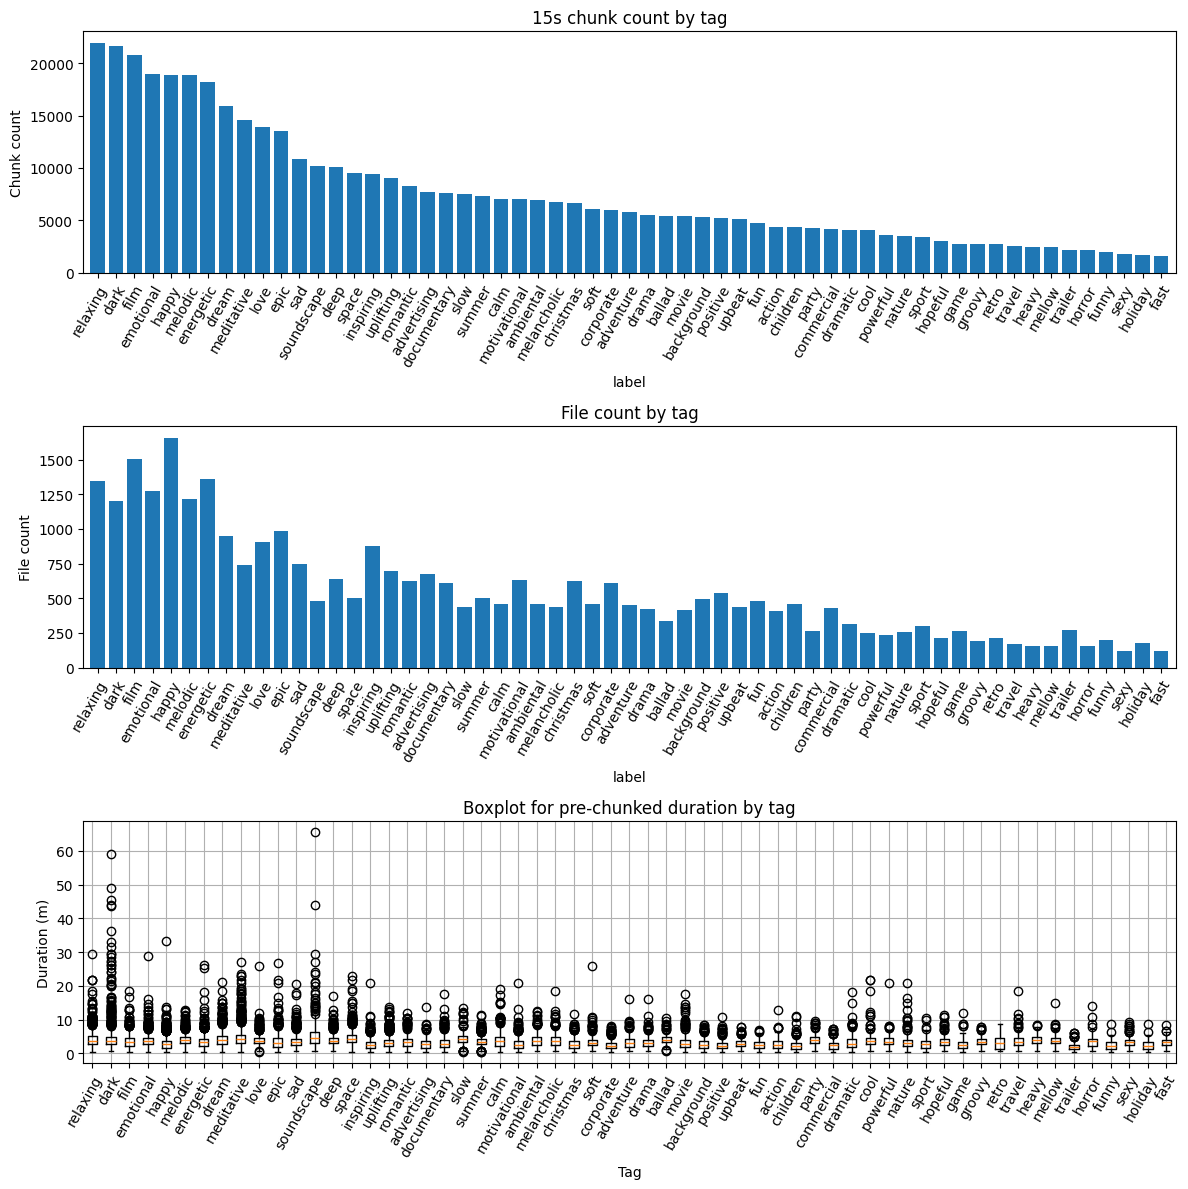

In [130]:
describe_split_labels("./autotagging_moodtheme.csv")

TRAIN split
56
{'drama', 'soundscape', 'trailer', 'game', 'summer', 'commercial', 'dream', 'christmas', 'sport', 'dramatic', 'hopeful', 'groovy', 'motivational', 'space', 'happy', 'inspiring', 'positive', 'slow', 'advertising', 'relaxing', 'retro', 'soft', 'romantic', 'holiday', 'party', 'deep', 'ballad', 'film', 'energetic', 'meditative', 'melodic', 'funny', 'cool', 'documentary', 'powerful', 'action', 'children', 'nature', 'movie', 'sad', 'travel', 'calm', 'heavy', 'background', 'fun', 'corporate', 'adventure', 'fast', 'emotional', 'epic', 'uplifting', 'melancholic', 'love', 'dark', 'upbeat', 'sexy'}

song_dur_min drama 22/25222.mp3
song_dur_min soundscape 48/17148.mp3
song_dur_min trailer 22/25222.mp3
song_dur_min game 22/25222.mp3
song_dur_min summer 22/25222.mp3
song_dur_min commercial 22/25222.mp3
song_dur_min dream 22/25222.mp3
song_dur_min christmas 22/25222.mp3
song_dur_min sport 22/25222.mp3
song_dur_min dramatic 22/25222.mp3
song_dur_min hopeful 48/17148.mp3
song_dur_min gro

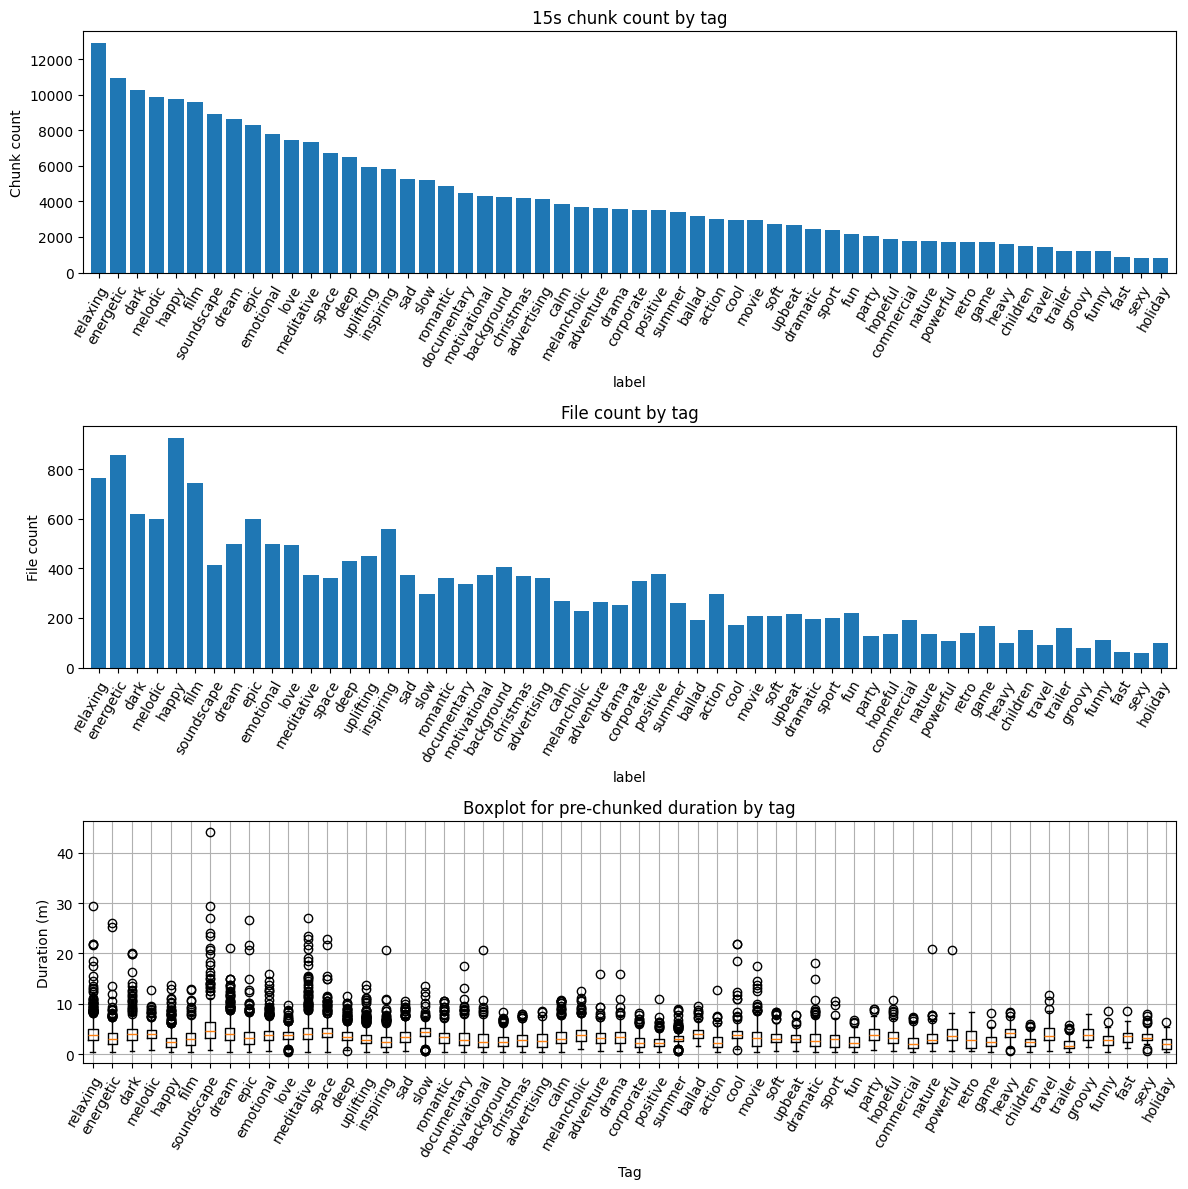

In [150]:
describe_split_labels("./autotagging_moodtheme-train_clean.csv")

VALIDATION split
56
{'drama', 'soundscape', 'trailer', 'game', 'summer', 'commercial', 'dream', 'christmas', 'sport', 'dramatic', 'hopeful', 'groovy', 'motivational', 'happy', 'space', 'inspiring', 'positive', 'slow', 'advertising', 'relaxing', 'retro', 'soft', 'romantic', 'party', 'holiday', 'deep', 'ballad', 'film', 'energetic', 'meditative', 'melodic', 'funny', 'cool', 'powerful', 'documentary', 'action', 'children', 'nature', 'movie', 'sad', 'travel', 'calm', 'heavy', 'corporate', 'fun', 'background', 'adventure', 'fast', 'emotional', 'epic', 'uplifting', 'melancholic', 'love', 'dark', 'upbeat', 'sexy'}

15s_chunk_sum 87213


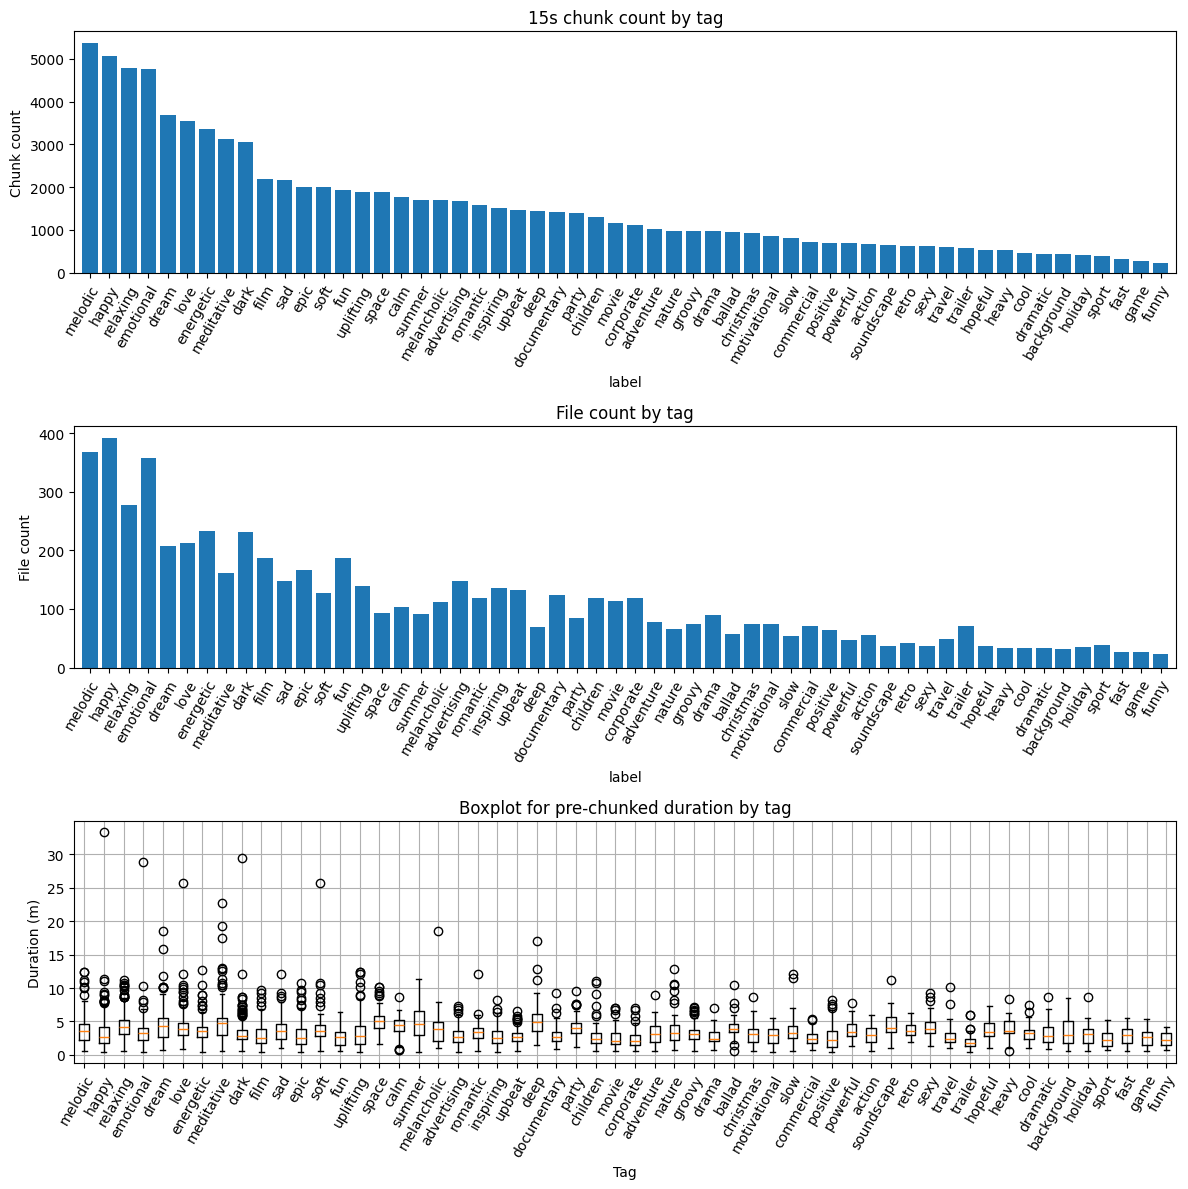

In [132]:
describe_split_labels("./autotagging_moodtheme-validation_clean.csv")

TEST split
56
{'drama', 'soundscape', 'trailer', 'game', 'summer', 'commercial', 'dream', 'christmas', 'sport', 'dramatic', 'hopeful', 'groovy', 'motivational', 'happy', 'space', 'inspiring', 'positive', 'slow', 'advertising', 'relaxing', 'retro', 'soft', 'romantic', 'party', 'holiday', 'ballad', 'deep', 'film', 'energetic', 'meditative', 'melodic', 'funny', 'cool', 'powerful', 'documentary', 'action', 'children', 'nature', 'movie', 'sad', 'travel', 'calm', 'heavy', 'corporate', 'background', 'fun', 'adventure', 'fast', 'emotional', 'epic', 'uplifting', 'melancholic', 'love', 'dark', 'upbeat', 'sexy'}

15s_chunk_sum 104140


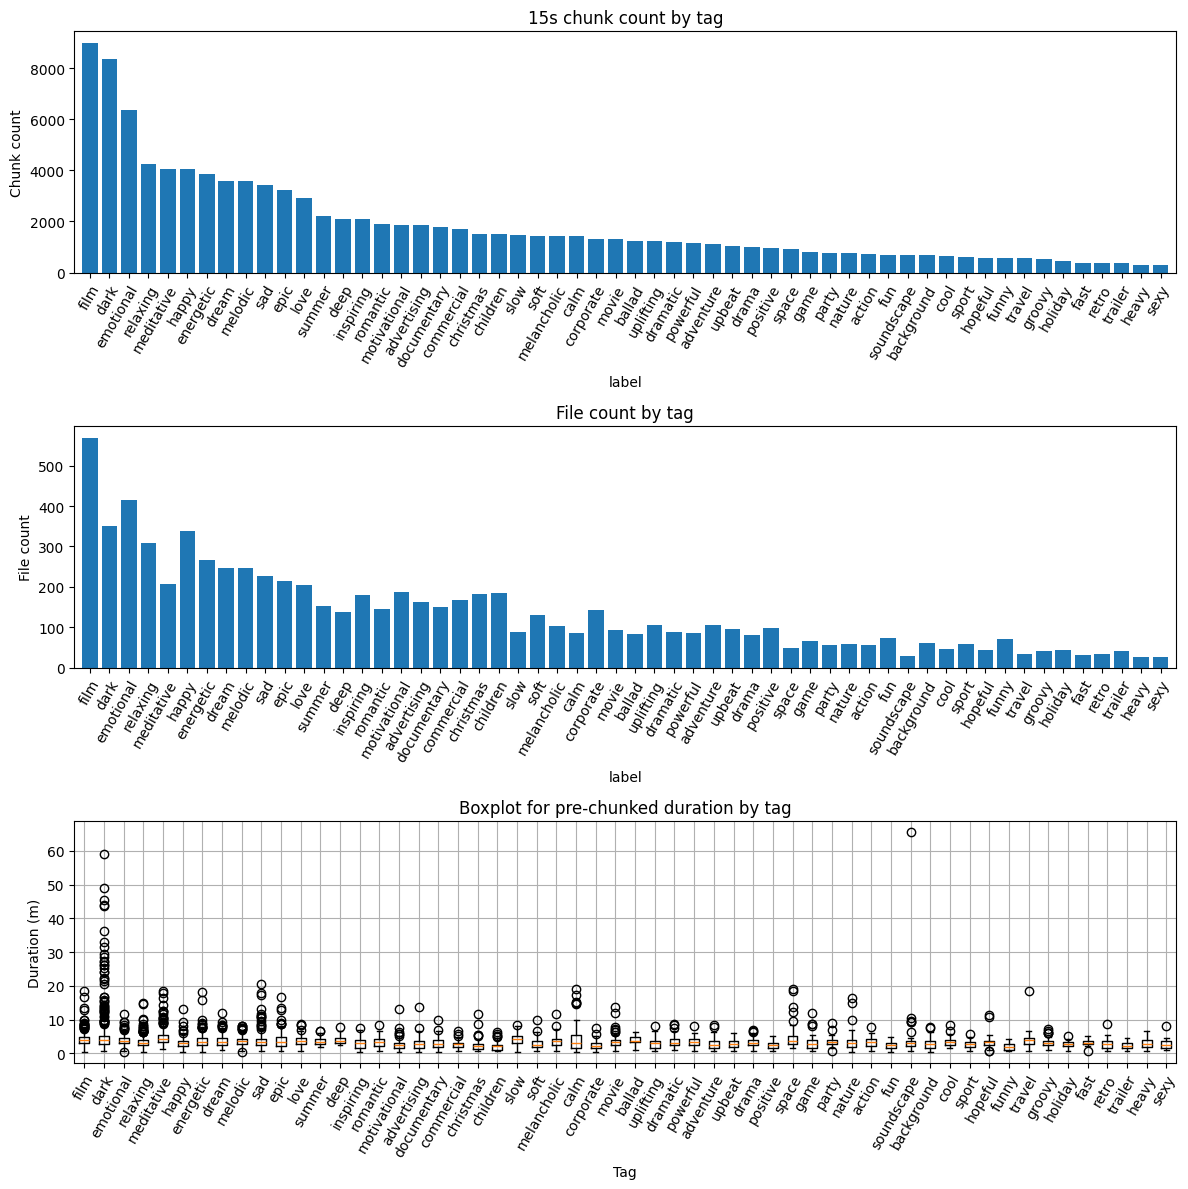

In [133]:
describe_split_labels("./autotagging_moodtheme-test_clean.csv")

# All files

In [108]:
def describe_all_splits(
    filenames: list[str],
    to_describe="count",
    y_label="",
    figsize=(12, 12),
    sort_index=False,
    no_title=False,
):
    sorted_groups = []

    for filename in filenames:
        df = pd.read_csv(filename)

        df = preprocess(df)

        unique_tags = set()

        def add_to_unique_tags(obj):
            for i in obj:
                unique_tags.add(i)

        df["TAGS"].apply(lambda x: add_to_unique_tags(x))

        # print(len(unique_tags))
        # print(unique_tags)
        # print()

        grouped = pd.DataFrame(
            columns=[
                "count",
                "dur_sum",
                "dur_mean",
                "dur_med",
                "dur_std",
                "dur_min",
                "dur_25%",
                "dur_50%",
                "dur_75%",
                "dur_max",
                "5s_chunk",
                "5s_chunk_dur",
                "5s_chunk_dur_str",
                "15s_chunk",
                "15s_chunk_dur",
                "15s_chunk_dur_str",
                "30s_chunk",
                "30s_chunk_dur",
                "30s_chunk_dur_str",
            ]
        )

        for ut in unique_tags:
            grouped.loc[ut, "count"] = list(df["TAGS"].apply(lambda x: ut in x)).count(
                True
            )

            dur_filter = df.where(df["TAGS"].apply(lambda x: ut in x))["DURATION"]
            dur_filter_sum = dur_filter.sum()

            grouped.loc[ut, "dur_sum"] = dur_filter_sum
            grouped.loc[ut, "dur_mean"] = dur_filter.mean()
            grouped.loc[ut, "dur_med"] = dur_filter.median()
            grouped.loc[ut, "dur_std"] = dur_filter.std()
            grouped.loc[ut, "dur_min"] = dur_filter.min()
            grouped.loc[ut, "dur_25%"] = dur_filter.quantile(0.25)
            grouped.loc[ut, "dur_50%"] = dur_filter.quantile(0.5)
            grouped.loc[ut, "dur_75%"] = dur_filter.quantile(0.75)
            grouped.loc[ut, "dur_max"] = dur_filter.max()

            five = int(dur_filter_sum // 5)
            grouped.loc[ut, "5s_chunk"] = five
            grouped.loc[ut, "5s_chunk_dur"] = five * 5
            grouped.loc[ut, "5s_chunk_dur_str"] = sec_to_hrs_str(five * 5)

            fifteen = int(dur_filter_sum // 15)
            grouped.loc[ut, "15s_chunk"] = fifteen
            grouped.loc[ut, "15s_chunk_dur"] = fifteen * 15
            grouped.loc[ut, "15s_chunk_dur_str"] = sec_to_hrs_str(fifteen * 15)

            thirty = int(dur_filter_sum // 30)
            grouped.loc[ut, "30s_chunk"] = thirty
            grouped.loc[ut, "30s_chunk_dur"] = thirty * 30
            grouped.loc[ut, "30s_chunk_dur_str"] = sec_to_hrs_str(thirty * 30)

        # print(grouped.sort_index())
        # print(grouped.head())

        if sort_index:
            sorted_groups.append(grouped.sort_index())
        else:
            sorted_groups.append(grouped.sort_values(by=to_describe, ascending=False))

    _, axes = plt.subplots(
        nrows=len(sorted_groups), ncols=1, figsize=figsize, constrained_layout=True
    )

    for i, sg in enumerate(sorted_groups):
        display_fn = ""
        try:
            what_split = f"{filenames[i].split("_")[1].split("-")[1].upper()}"
            match what_split:
                case "TRAIN":
                    display_fn = "pelatihan"
                case "VALIDATION":
                    display_fn = "validasi"
                case "TEST":
                    display_fn = "pengujian"
        except:
            display_fn = filenames[i]

        # Plot by chunk count
        if y_label != "":
            ylabel = f"Banyak {y_label}"
        else:
            ylabel = ""

        if len(filenames) == 1:
            bar_plotter(
                x=sg.index,
                height=sg[to_describe],
                xlabel="",
                ylabel=ylabel,
                ax=axes,
                rotation=60,
            )
            if not no_title:
                axes.set_title(f"Banyak {y_label} tiap label di split {display_fn}")
            axes.grid(alpha=0.7)
            # axes.set_axisbelow(True)
        else:
            bar_plotter(
                x=sg.index,
                height=sg[to_describe],
                xlabel="",
                ylabel=ylabel,
                ax=axes[i],
                rotation=60,
            )
            if not no_title:
                axes[i].set_title(f"Banyak {y_label} tiap label di split {display_fn}")
            axes[i].grid(alpha=0.7)
            # axes[i].set_axisbelow(True)

    # plt.tight_layout()
    plt.show()

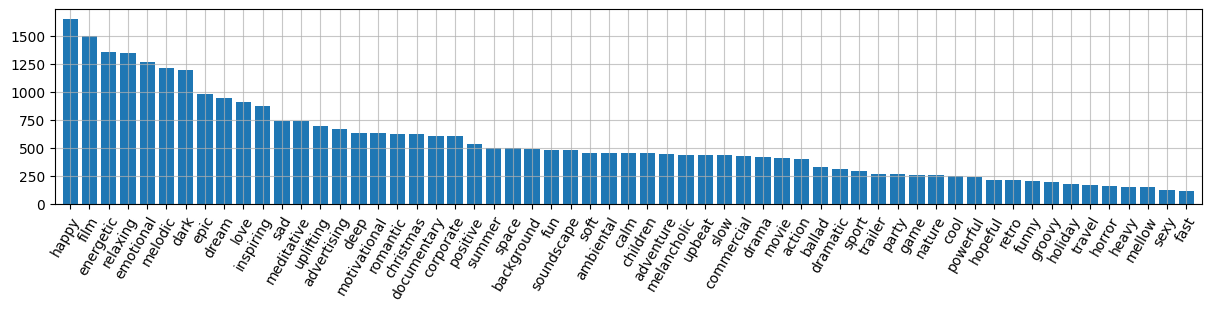

In [109]:
describe_all_splits(
    [
        "./autotagging_moodtheme.csv",
    ],
    # y_label="berkas",
    figsize=(12, 3),
    no_title=True
)

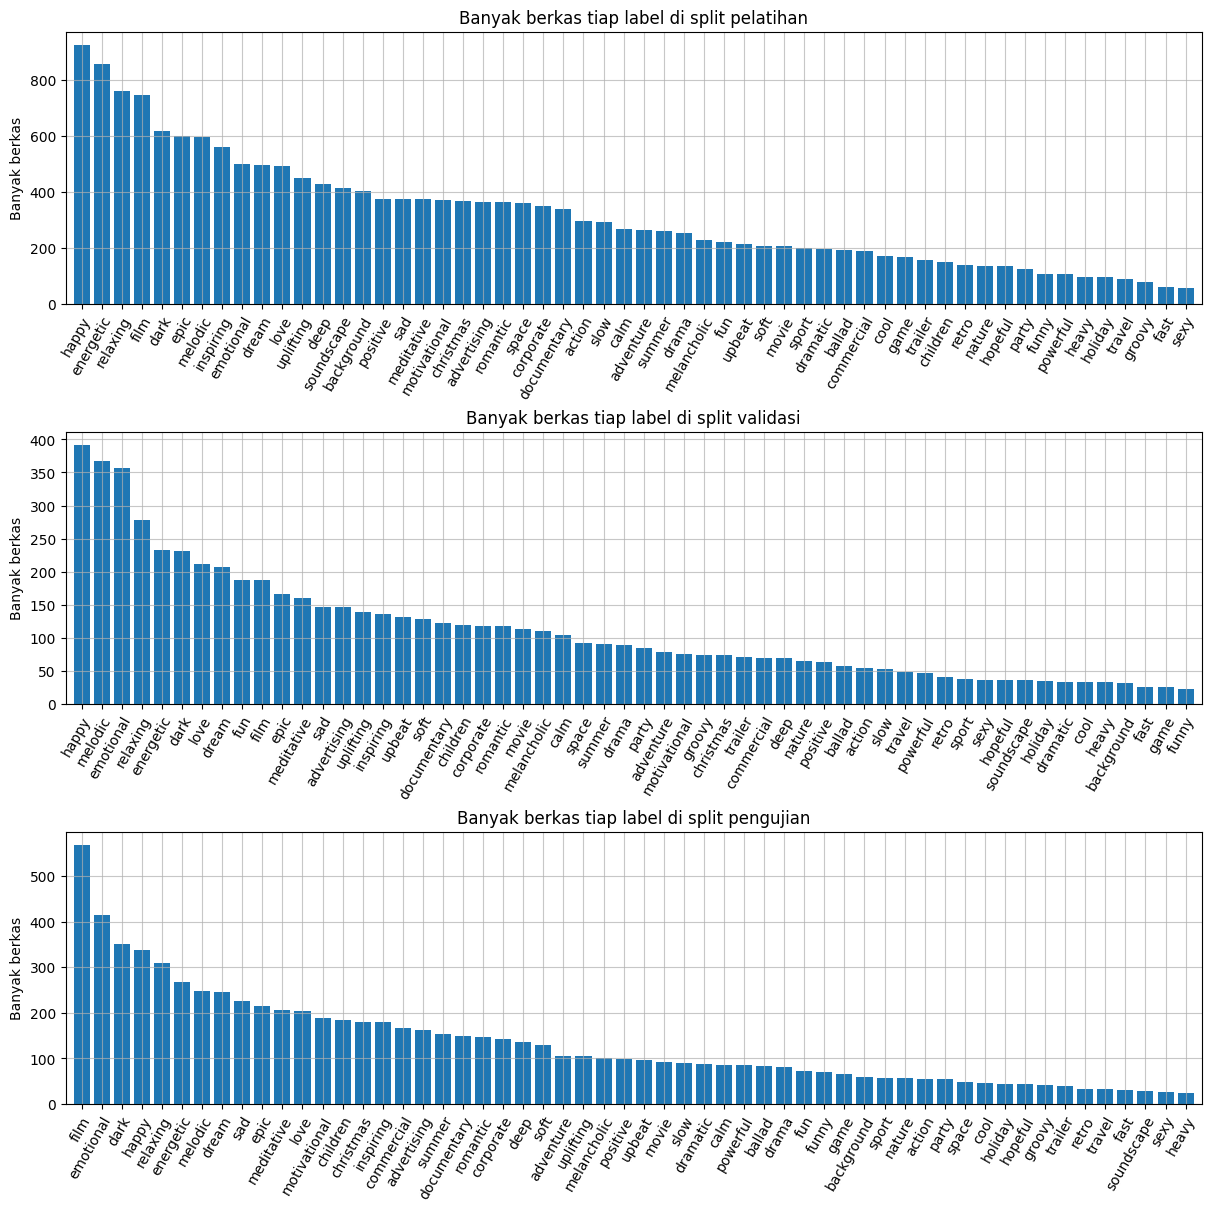

In [110]:
describe_all_splits(
    [
        "./autotagging_moodtheme-train_clean.csv",
        "./autotagging_moodtheme-validation_clean.csv",
        "./autotagging_moodtheme-test_clean.csv",
    ],
    y_label="berkas",
)

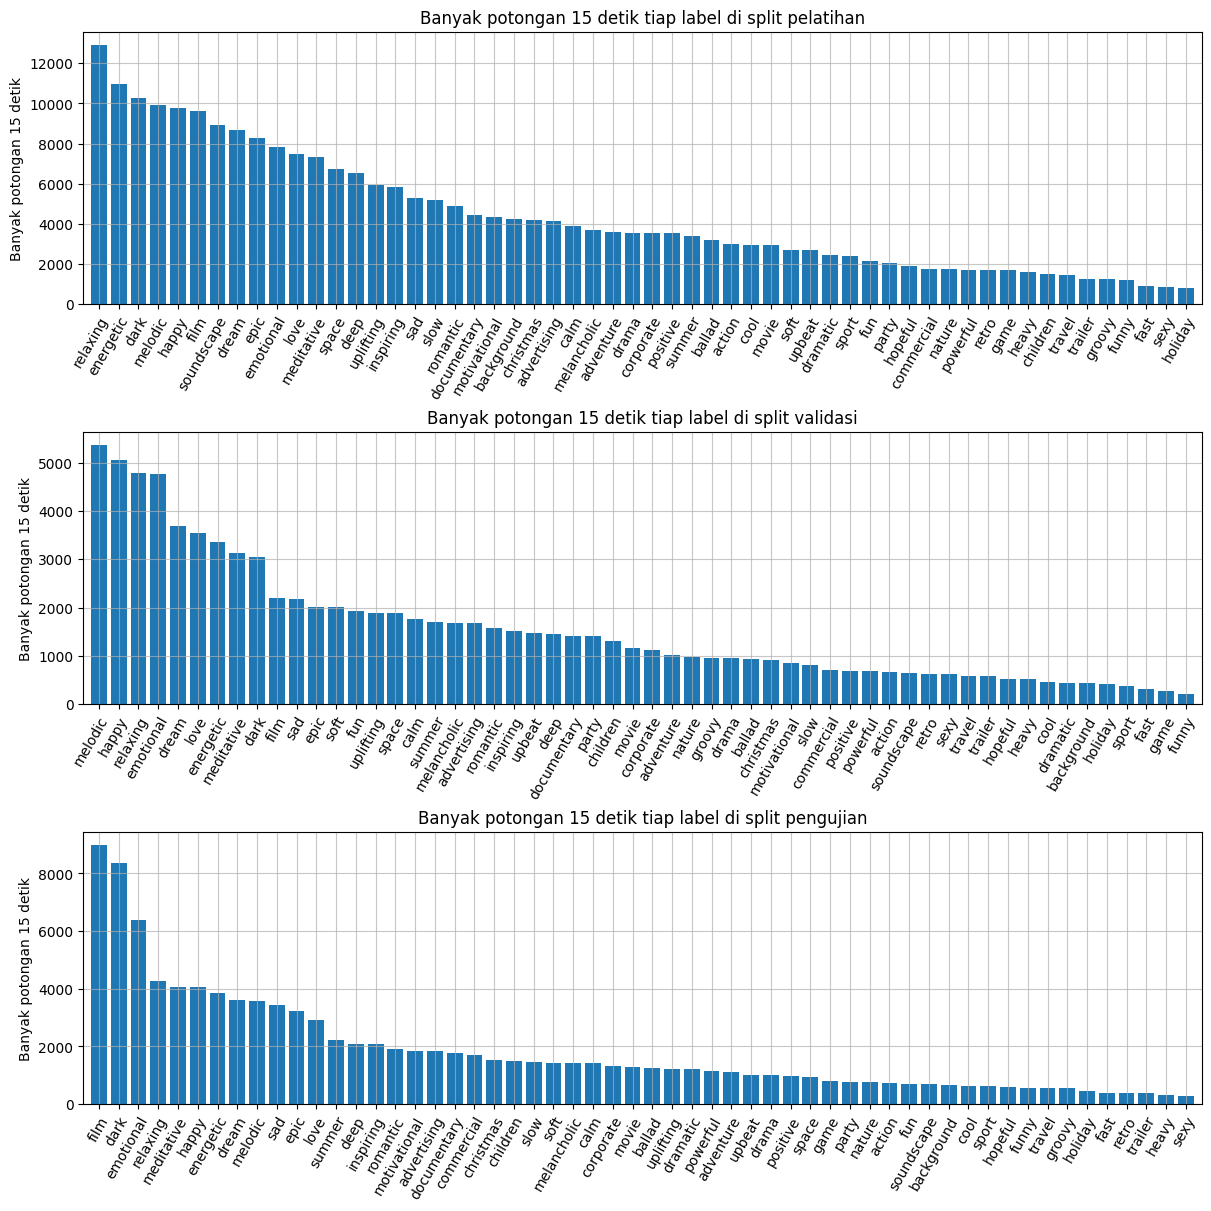

In [111]:
describe_all_splits(
    [
        "./autotagging_moodtheme-train_clean.csv",
        "./autotagging_moodtheme-validation_clean.csv",
        "./autotagging_moodtheme-test_clean.csv",
    ],
    to_describe="15s_chunk",
    y_label="potongan 15 detik"
)